# Aula 8 – Análise de Sentimentos – Exemplo 3

**Objetivo:** apresentar uma versão mais próxima de um fluxo profissional, mantendo transparência conceitual e boas práticas metodológicas.

Neste notebook, consolidamos os conceitos introduzidos nos exemplos anteriores e avançamos para um pipeline mais robusto e reprodutível, semelhante ao utilizado em projetos reais de PLN.

Principais aspectos abordados:

- controle de aleatoriedade e reprodutibilidade dos experimentos;
- uso de **Pipeline** para integrar vetorização (TF-IDF) e classificador;
- ajuste de hiperparâmetros com **GridSearchCV** e validação cruzada;
- avaliação detalhada com métricas e matriz de confusão;
- análise de interpretabilidade por meio dos termos mais influentes;
- função de inferência com estimativa de probabilidade e detecção de incerteza.

Este exemplo tem como foco mostrar **como organizar, avaliar e interpretar** um modelo de Análise de Sentimentos de forma metodologicamente sólida, sem perder de vista os fundamentos apresentados anteriormente.


## 1. Setup e reprodutibilidade do experimento

Neste notebook, definimos uma semente global de aleatoriedade logo no início.
Isso garante que todas as etapas do pipeline — divisão de dados, validação cruzada
e treinamento de modelos — produzam resultados reprodutíveis.

Esse cuidado é essencial em fluxos profissionais e científicos, onde resultados
devem ser consistentes entre execuções e ambientes diferentes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Mini-corpus rotulado


Neste notebook, utilizamos **15 textos positivos e 15 textos negativos**, totalizando **30 exemplos**.  
No exemplo anterior, o corpus continha **10 textos de cada classe**.

Essa diferença é intencional e tem objetivos didáticos e metodológicos claros.


### Por que aumentar o número de exemplos?

À medida que o pipeline se torna mais robusto (Pipeline, validação cruzada, ajuste de hiperparâmetros), cresce também a necessidade de:

- maior **estabilidade estatística** nas métricas;
- redução do impacto de exemplos individuais;
- avaliações mais confiáveis durante a validação cruzada.

Com apenas 10 exemplos por classe, pequenas variações podem alterar significativamente:
- a seleção de hiperparâmetros;
- o valor das métricas;
- o modelo considerado “melhor”.

O aumento para 15 exemplos por classe **não resolve o problema de dados escassos**, mas **atenua seus efeitos**.


### Relação com a validação cruzada

Neste exemplo, utilizamos **validação cruzada** (`GridSearchCV`).  
Para que essa técnica seja minimamente informativa, é desejável que:

- cada *fold* contenha exemplos de ambas as classes;
- a divisão não seja excessivamente sensível a um único texto.

Um corpus ligeiramente maior ajuda a:
- manter a proporção das classes em cada *fold*;
- tornar a comparação entre configurações mais estável.


### Coerência com a progressão didática

A evolução do tamanho do corpus acompanha a evolução do notebook:

- **Exemplo 1** → foco em compreensão conceitual (corpus mínimo)  
- **Exemplo 2** → melhoria de desempenho com boas práticas básicas  
- **Exemplo 3** → organização experimental e avaliação mais robusta  

Assim, o aumento do número de textos reforça a ideia de que:
> pipelines mais sofisticados exigem maior cuidado com dados e avaliação.


### Observação importante

Mesmo com 30 exemplos, este corpus continua sendo **didático**.  
Em aplicações reais de Análise de Sentimentos, são normalmente necessários **centenas ou milhares de textos** para resultados confiáveis.

O objetivo aqui não é alcançar desempenho máximo, mas **demonstrar boas práticas experimentais**.


In [3]:
textos = [
    # positivos
    "O produto é ótimo",
    "O produto é excelente",
    "Gostei muito do produto",
    "A experiência foi excelente",
    "Atendimento rápido e ótimo",
    "Serviço muito bom",
    "Entrega foi rápida e ótima",
    "Estou satisfeito com o atendimento",
    "O sistema funciona muito bem",
    "Valeu a pena comprar",
    "Qualidade muito boa e entrega rápida",
    "Suporte resolveu meu problema rapidamente",
    "Gostei do atendimento e do produto",
    "Compra excelente, recomendo",
    "Muito satisfeito com o serviço",

    # negativos
    "O produto é ruim",
    "O produto é péssimo",
    "Não gostei do produto",
    "A experiência foi ruim",
    "Atendimento lento e péssimo",
    "Serviço muito ruim",
    "A entrega foi atrasada e ruim",
    "Estou insatisfeito com o atendimento",
    "O sistema falha e é ruim",
    "Não valeu a pena comprar",
    "Qualidade ruim e entrega atrasada",
    "Suporte não resolveu meu problema",
    "Atendimento péssimo, não recomendo",
    "Compra ruim, fiquei insatisfeito",
    "Muito decepcionado com o serviço",
]
# rótulos
sentimentos = np.array([1]*15 + [0]*15)
print("N:", len(textos), "| positivo:", int(sentimentos.sum()), "| negativo:", int((1-sentimentos).sum()))

N: 30 | positivo: 15 | negativo: 15


## 3. Split treino/teste

Nesta etapa, dividimos o conjunto de dados rotulados em duas partes distintas:

- conjunto de treino → usado para ajustar o pipeline e escolher hiperparâmetros (via validação cruzada)
- conjunto de teste → reservado como avaliação final em dados não vistos (*hold-out*)

Essa separação é essencial para responder à pergunta:

> *O modelo realmente generaliza para novos textos, ou está apenas se ajustando ao conjunto de treino?*

### Por que isso é ainda mais importante neste exemplo?

Como o Exemplo 3 utiliza **Pipeline** e **GridSearchCV**, o conjunto de treino será usado repetidamente durante a **validação cruzada** para comparar configurações do modelo.  
Por isso, o conjunto de teste deve permanecer **intocado** até o final, evitando **vazamento de dados** e garantindo uma estimativa mais honesta de desempenho.

> Observação: a reprodutibilidade deste split é garantida pela semente global
definida no início do notebook.


In [5]:
from sklearn.model_selection import train_test_split

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    textos,
    sentimentos,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=sentimentos
)

print("Treino:", len(X_train_txt), "| Teste:", len(X_test_txt))

Treino: 21 | Teste: 9


## 4. Pipeline + GridSearchCV (ajuste sistemático do modelo)

Nesta etapa, organizamos todo o fluxo de Análise de Sentimentos em um pipeline reprodutível e realizamos o **ajuste sistemático de hiperparâmetros** por meio de validação cruzada.

O objetivo é aproximar o experimento de um **cenário profissional**, evitando decisões manuais e reduzindo vieses na escolha do modelo.


### Uso de Pipeline

O objeto `Pipeline` integra, em uma única estrutura:

- a **vetorização do texto** (TF-IDF);
- o **classificador** (Regressão Logística).

Isso garante que:
- todas as etapas sejam aplicadas corretamente dentro de cada *fold* da validação cruzada;
- não haja **vazamento de dados** entre treino e validação;
- o código permaneça organizado, modular e reutilizável.



### Ajuste de hiperparâmetros com GridSearchCV

Em vez de fixar manualmente valores para o modelo, utilizamos `GridSearchCV` para testar **combinações de parâmetros** e selecionar aquela que apresenta melhor desempenho médio.

Os parâmetros avaliados incluem:

- **TF-IDF**
  - `ngram_range`: uso de unigramas ou unigramas + bigramas;
  - `min_df`: frequência mínima para inclusão de termos no vocabulário;
  - `sublinear_tf`: aplicação de escala logarítmica na frequência dos termos.

- **Regressão Logística**
  - `C`: intensidade da regularização;
  - `class_weight`: ponderação das classes para lidar com possíveis desequilíbrios.

A avaliação é feita por **validação cruzada com 5 *folds*** (`cv=5`), utilizando a métrica **F1-score**, adequada para tarefas de classificação em que erros de uma classe são tão relevantes quanto da outra.


### Interpretação do resultado

Ao final da busca, o `GridSearchCV` retorna:

- o **melhor valor médio de F1-score** obtido na validação cruzada;
- o **conjunto de hiperparâmetros** que produziu esse resultado.

Esses valores representam a configuração que, em média, apresentou o melhor equilíbrio entre precisão e revocação no conjunto de treino.

É importante destacar que:
- esse resultado ainda não corresponde à avaliação final do modelo;
- o conjunto de teste permanece reservado para uma etapa posterior, garantindo uma estimativa honesta de desempenho.


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=500, random_state=RANDOM_STATE)),
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "tfidf__sublinear_tf": [True, False],
    "clf__C": [0.5, 1.0, 2.0],
    "clf__class_weight": [None, "balanced"],
}

grid = GridSearchCV(pipe, param_grid, scoring="f1", cv=5, n_jobs=-1)
grid.fit(X_train_txt, y_train)

print("Melhor F1 (CV):", grid.best_score_)
print("Melhores parâmetros:", grid.best_params_)

Melhor F1 (CV): 0.7942857142857143
Melhores parâmetros: {'clf__C': 2.0, 'clf__class_weight': None, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}


### Analisando o resultado

`Melhor F1 (CV): 0.7942857142857143`

Esse valor indica o melhor F1-score médio obtido durante a validação cruzada, considerando todas as combinações de hiperparâmetros testadas pelo `GridSearchCV`.

Em termos práticos:

- o conjunto de treino foi dividido em 5 folds (`cv=5`);
- para cada combinação de parâmetros:
  - o modelo foi treinado 5 vezes;
  - em cada vez, um fold diferente foi usado como validação;
- o F1-score médio dessas 5 execuções foi calculado;
- 0.79 foi o maior valor médio encontrado.

👉 Portanto:

> 0.79 não é o desempenho no conjunto de teste,
é o desempenho médio esperado no treino, estimado via validação cruzada.


`Melhores parâmetros: {...}`: esse dicionário mostra a configuração específica do pipeline que produziu o melhor F1 médio.


## 5. Avaliação do modelo no conjunto de teste

Após o ajuste sistemático de hiperparâmetros com **GridSearchCV**, avaliamos o desempenho do **modelo selecionado automaticamente** no conjunto de teste.

Esse conjunto de teste permaneceu **intocado durante todo o processo de validação cruzada**, o que garante uma estimativa mais honesta da capacidade de generalização do modelo.


### O que está sendo avaliado aqui?

- `best_model` corresponde ao **pipeline completo** (TF-IDF + classificador) com os **melhores hiperparâmetros**, conforme determinado pela validação cruzada;
- as previsões são feitas em **dados não vistos** nem no treinamento nem na validação interna.


### Métricas utilizadas

- `classification_report` fornece métricas quantitativas por classe:
  - *precision*, *recall* e *F1-score*;
- a **matriz de confusão** explicita:
  - acertos e erros por classe;
  - o tipo de erro cometido pelo modelo (falsos positivos e falsos negativos).


> Enquanto a validação cruzada orienta a escolha do melhor modelo,  
> a avaliação no conjunto de teste fornece a **medida final de desempenho** do experimento.


              precision    recall  f1-score   support

 negativo(0)       0.80      0.80      0.80         5
 positivo(1)       0.75      0.75      0.75         4

    accuracy                           0.78         9
   macro avg       0.78      0.78      0.78         9
weighted avg       0.78      0.78      0.78         9



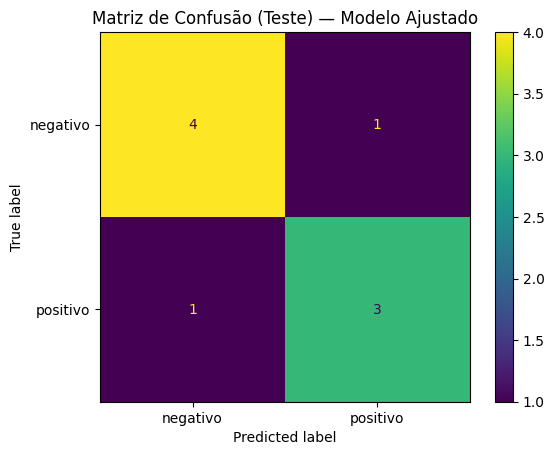

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_txt)

print(classification_report(y_test, y_pred, target_names=["negativo(0)","positivo(1)"]))

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negativo","positivo"]).plot()
plt.title("Matriz de Confusão (Teste) — Modelo Ajustado")
plt.show()

## 6. Interpretabilidade: termos mais influentes por classe (aproximação)

Até aqui, avaliamos o modelo apenas pelo seu **desempenho quantitativo**.  
Nesta etapa, avançamos para uma análise qualitativa: **quais termos do vocabulário mais influenciam as decisões do classificador?**

Essa análise busca tornar o modelo **mais transparente**, permitindo relacionar decisões automáticas com elementos linguísticos concretos.


### Fundamento da interpretação

A Regressão Logística é um **modelo linear**. Isso significa que:

- cada termo do vocabulário (palavra ou n-grama) possui um **coeficiente** associado;
- o sinal do coeficiente indica a direção da influência:
  - coeficiente **positivo** → favorece a classe positiva;
  - coeficiente **negativo** → favorece a classe negativa;
- o valor absoluto indica a **intensidade da influência**.

Essa propriedade permite uma interpretação direta dos parâmetros aprendidos.


### Como interpretar o resultado

- Termos listados como **positivos** são aqueles que, quando presentes, aumentam a probabilidade da classe positiva.
- Termos listados como **negativos** têm o efeito oposto.

In [ ]:
tfidf = best_model.named_steps["tfidf"]
clf = best_model.named_steps["clf"]

feat = tfidf.get_feature_names_out()
coefs = clf.coef_[0]

top_n = 10
idx_pos = np.argsort(coefs)[-top_n:][::-1]
idx_neg = np.argsort(coefs)[:top_n]

print("Top termos (positivos):")
for i in idx_pos:
    print(f"  {feat[i]:30s} coef={coefs[i]: .4f}")

print("Top termos (negativos):")
for i in idx_neg:
    print(f"  {feat[i]:30s} coef={coefs[i]: .4f}")

Top termos (positivos):
  excelente                      coef= 0.8327
  muito                          coef= 0.7466
  rápida                         coef= 0.6884
  do                             coef= 0.4351
  foi                            coef= 0.2264
  gostei                         coef= 0.2048
  entrega                        coef= 0.1612
  sistema                        coef= 0.0694
  valeu                          coef= 0.0512
  pena                           coef= 0.0512
Top termos (negativos):
  ruim                           coef=-1.8617
  não                            coef=-1.3532
  com                            coef=-0.2380
  produto                        coef=-0.1892
  serviço                        coef=-0.1162
  compra                         coef=-0.0190
  comprar                        coef= 0.0512
  pena                           coef= 0.0512
  valeu                          coef= 0.0512
  sistema                        coef= 0.0694


## 7. Função de inferência com estimativa de incerteza

Nesta etapa, encapsulamos o modelo treinado em uma **função de inferência**, simulando o uso do classificador em um cenário real de aplicação.

Diferentemente das etapas anteriores, o foco aqui não é mais o treinamento ou a avaliação global, mas sim:
- a **predição individual** de novos textos;
- a **interpretação da confiança** do modelo em cada decisão.


### O que a função faz

A função `classificar_sentimento` executa os seguintes passos para um texto de entrada:

1. **Calcula as probabilidades das classes**  
   Utiliza `predict_proba` para estimar:
   - `p_neg`: probabilidade do texto ser negativo;
   - `p_pos`: probabilidade do texto ser positivo.

2. **Determina a classe prevista**  
   A classe com maior probabilidade é selecionada como predição final.

3. **Avalia o grau de incerteza da decisão**  
   A diferença entre as probabilidades (`|p_pos - p_neg|`) é comparada a um limiar (`limiar_incerteza`).

   - Se a diferença for grande o suficiente → decisão considerada **confiável** (`status = "ok"`);
   - Se a diferença for pequena → decisão marcada como **incerta**, indicando ambiguidade do texto ou limitação do modelo.

4. **Retorna um dicionário estruturado**  
   Com o texto analisado, a predição, as probabilidades e o status da decisão.


### Interpretação dos resultados

- Predições com probabilidades claramente distintas (por exemplo, `p_pos ≈ 0.70`) indicam maior confiança do modelo.
- Predições com probabilidades próximas (por exemplo, `0.51 × 0.49`) refletem **incerteza**, mesmo que uma classe seja escolhida.

Esse comportamento é esperado, especialmente em textos:
- ambíguos;
- curtos;
- ou que contenham sinais conflitantes.


### Por que explicitar a incerteza?

Em aplicações reais de Análise de Sentimentos:
- decisões automáticas **nem sempre devem ser tratadas como absolutas**;
- casos incertos podem ser:
  - revisados manualmente;
  - encaminhados para outro modelo;
  - descartados ou sinalizados ao usuário.

Incluir a noção de incerteza torna o sistema:
- mais **responsável**;
- mais **transparente**;
- mais alinhado a boas práticas de engenharia de sistemas baseados em aprendizado de máquina.


In [15]:
def classificar_sentimento(texto, limiar_incerteza=0.08):
    proba = best_model.predict_proba([texto])[0]
    p_neg, p_pos = float(proba[0]), float(proba[1])
    pred = int(np.argmax(proba))
    status = "ok" if abs(p_pos - p_neg) >= limiar_incerteza else "incerto (margem pequena)"
    return {"texto": texto, "predicao": pred, "p_neg": p_neg, "p_pos": p_pos, "status": status}

tests = [
    "A entrega foi boa",
    "Estou satisfeito com o produto",
    "Atendimento lento e péssimo",
    "Não gostei do produto",
    "Entrega rápida e ótima",
]
for test in tests:
    print(classificar_sentimento(test))

{'texto': 'A entrega foi boa', 'predicao': 1, 'p_neg': 0.37499109003067743, 'p_pos': 0.6250089099693226, 'status': 'ok'}
{'texto': 'Estou satisfeito com o produto', 'predicao': 0, 'p_neg': 0.5167059700989712, 'p_pos': 0.48329402990102877, 'status': 'incerto (margem pequena)'}
{'texto': 'Atendimento lento e péssimo', 'predicao': 1, 'p_neg': 0.44107670526352394, 'p_pos': 0.5589232947364761, 'status': 'ok'}
{'texto': 'Não gostei do produto', 'predicao': 0, 'p_neg': 0.5538882365573383, 'p_pos': 0.4461117634426617, 'status': 'ok'}
{'texto': 'Entrega rápida e ótima', 'predicao': 1, 'p_neg': 0.29825228181717856, 'p_pos': 0.7017477181828214, 'status': 'ok'}
